In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# 1. Load the Iris dataset
iris = load_iris()

# Convert it to a Pandas DataFrame to act like a loaded CSV
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map the target integers (0, 1, 2) to actual species names for better readability
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# --- Exploratory Data Analysis (EDA) ---

print("--- First 5 Rows ---")
display(df.head()) 

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values ---")
display(df.isnull().sum())

Matplotlib is building the font cache; this may take a moment.


--- First 5 Rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB

--- Statistical Summary ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Missing Values ---


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

C:\Users\KN GROUP\AppData\Local\Temp\ipykernel_7256\3696287235.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal length (cm)', data=df, palette='pastel')


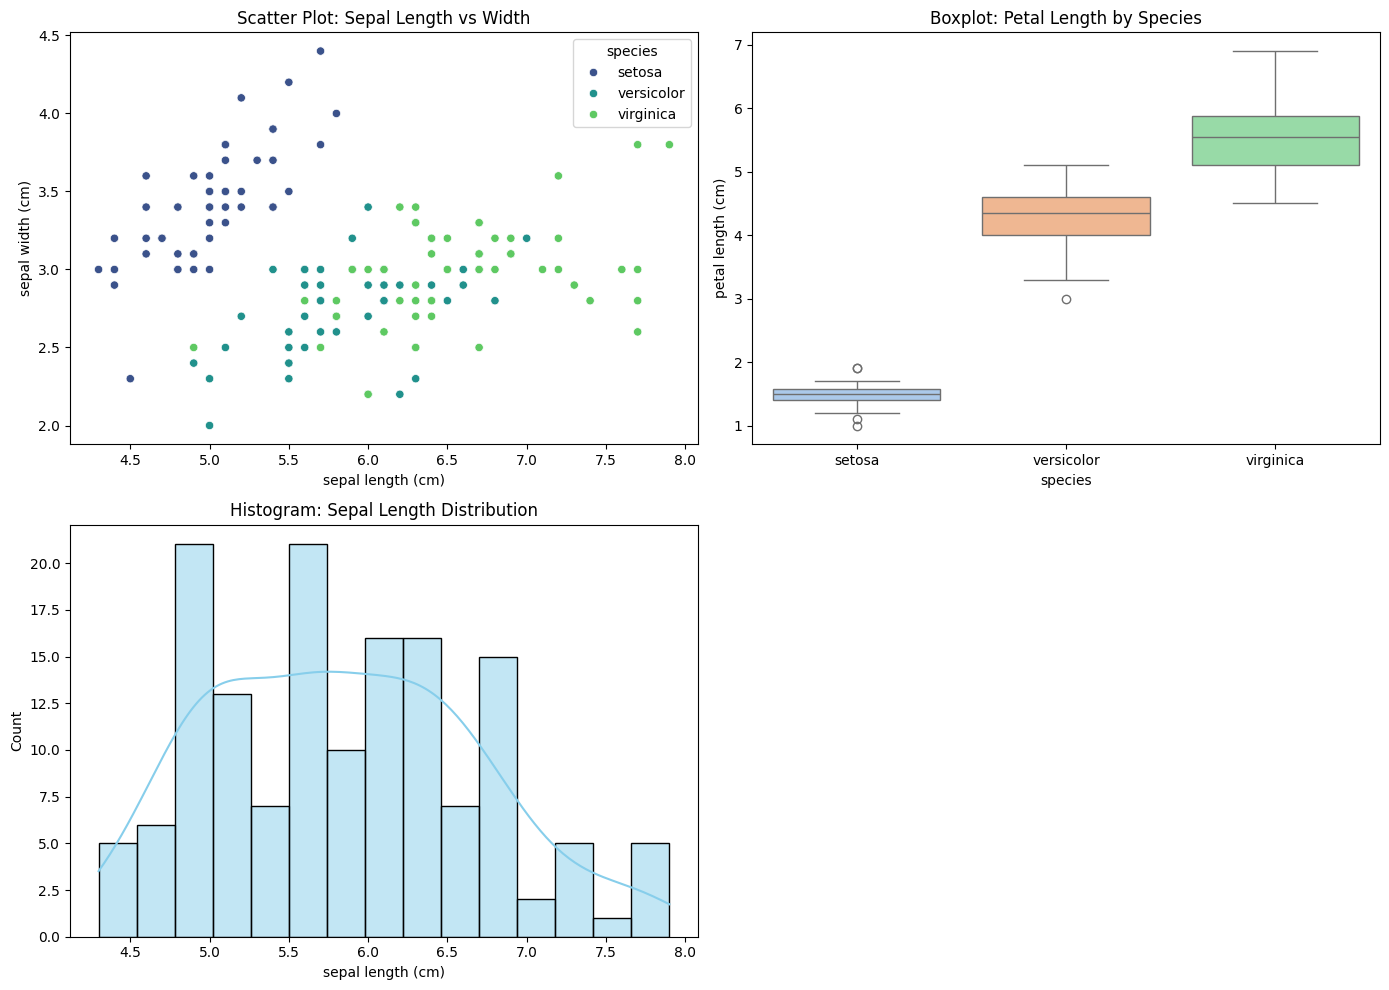


--- Pairplot ---


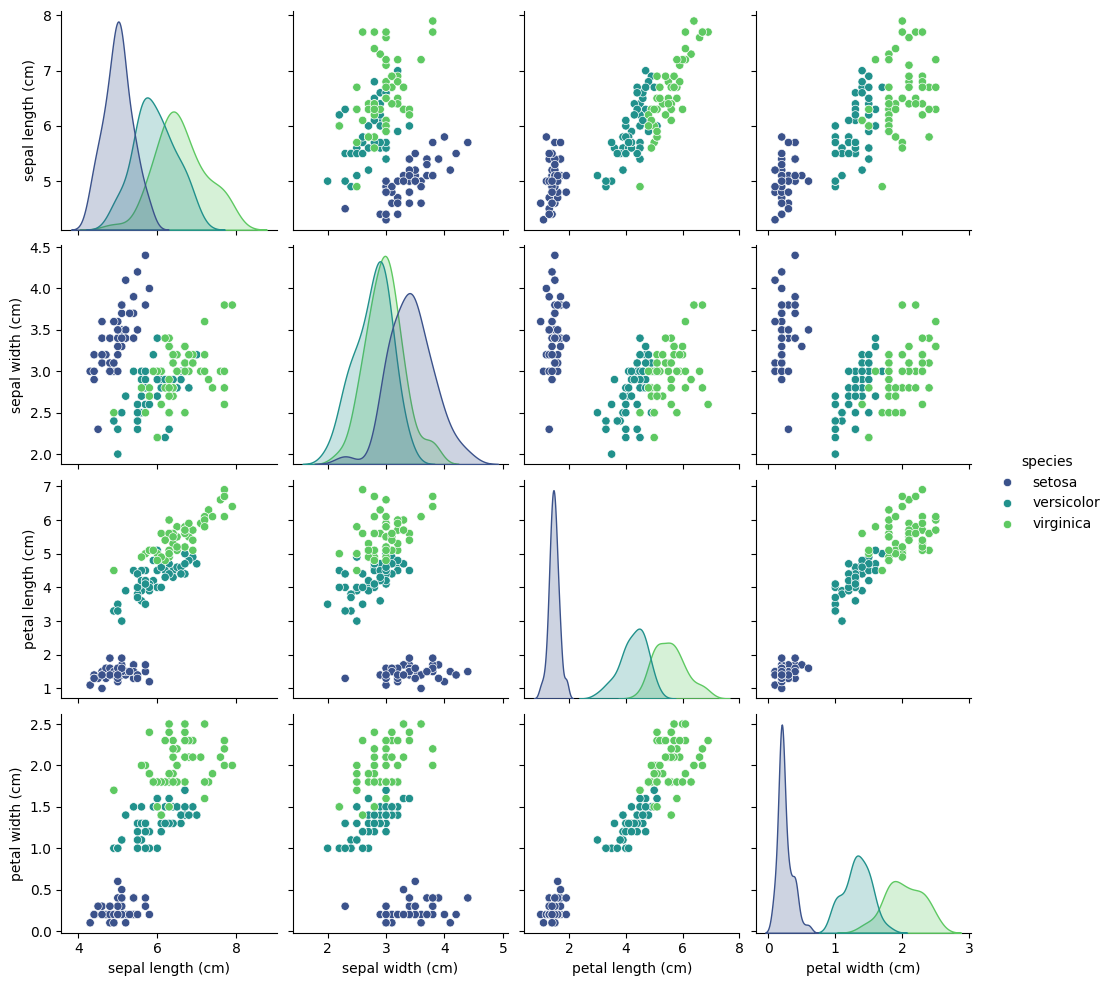

In [2]:
# --- Step 3: Data Visualization ---
# Set up a figure with multiple subplots for the first three charts
plt.figure(figsize=(14, 10))

# 1. Scatter Plot: Sepal Length vs Sepal Width
plt.subplot(2, 2, 1)
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species', data=df, palette='viridis')
plt.title('Scatter Plot: Sepal Length vs Width')

# 2. Boxplot: Petal Length across Species
plt.subplot(2, 2, 2)
sns.boxplot(x='species', y='petal length (cm)', data=df, palette='pastel')
plt.title('Boxplot: Petal Length by Species')

# 3. Histogram: Distribution of Sepal Length
plt.subplot(2, 2, 3)
sns.histplot(df['sepal length (cm)'], kde=True, bins=15, color='skyblue')
plt.title('Histogram: Sepal Length Distribution')

# Adjust the layout so the titles don't overlap
plt.tight_layout()
plt.show()

# 4. Pairplot: Relationships between all features
# (Pairplot creates its own standalone figure, so we run it separately)
print("\n--- Pairplot ---")
sns.pairplot(df, hue='species', palette='viridis')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- Step 4: Train the Baseline Model ---

# 1. Separate the features (X) from the target variable (y)
X = df.drop('species', axis=1)
y = df['species']

# 2. Split into training data (80%) and testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Logistic Regression model
# (We set max_iter=200 to ensure the math has enough time to converge)
model = LogisticRegression(max_iter=200)

# 4. Train the model using the training data
model.fit(X_train, y_train)

# 5. Make predictions on our unseen test data
y_pred = model.predict(X_test)

# 6. Report the metrics
print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# --- Step 5: Save the Artifact ---

# Save the trained model to your local workspace
joblib.dump(model, 'iris_logistic_regression_model.pkl')
print("\nSuccess! Model saved as 'iris_logistic_regression_model.pkl'")

--- Model Evaluation ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Success! Model saved as 'iris_logistic_regression_model.pkl'
